## Workflow

This notebook contains the main workflow of the project: synthetic data generation, primary strategy construction, IC analysis, triple-barrier labeling, and the secondary meta-labeling model.

For now, the data-generation process and the primary strategy remain inside the notebook for readability and continuity with earlier work. These sections can be collapsed. The reusable later-stage components are imported from separate `.py` files.

### Data Generation



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


rng = np.random.default_rng(0)


# Parameter specification with scales chosen to be realistic for daily returns

N = 500
T = 10000
K = 10

dates = pd.date_range("1986-01-01", periods=T, freq="B")
cols = [f"Stock_{i:03d}" for i in range(N)]

target_daily_vol = 0.10/np.sqrt(252)  # target annualized volatility (converted to daily)
# split total variance (vol**2) in factor and specific components
split = [0.6, 0.4]  # 60% factor, 40% specific

trend_daily = (0.50/252) # trend return 

print(f"Target total daily volatility: {target_daily_vol:.4f}"  )
print(f"Target total annual volatility: {target_daily_vol*np.sqrt(252):.4f}"  )

n_up, n_down = 200, 100       # number of stocks with an upward/downward trend



Target total daily volatility: 0.0063
Target total annual volatility: 0.1000


In [2]:
wi = np.ones([N,1])/N  # define equal weights for all stocks in the universe
# build covariaance matrix and beta and generate random process of returns

Z = np.random.normal(0, 1, size=(N, K-1))    # factor loadings with mean 0 and std 1
Z = ((Z - Z.mean(axis=1, keepdims=True)) / Z.std(axis=1, keepdims=True)) # standardize factor loadings
Z = np.concatenate([np.random.uniform(0.5, 1.5, size=(N, 1)), Z], axis=1)  # market factor with positive loading of around 1 for all stocks

G = np.diag(np.concatenate([np.ones(1), [0.25 * (np.exp(-i)) for i in range(K-1)]]))  # factor covariance matrix with decaying eigenvalues to be re-scaled to match the target factor variance
# G = np.diag(np.concatenate([np.ones(1),np.linspace(0.16,0.01,num=K-1)]))
S = np.random.uniform(0.01, 0.25, size=N) # specific variances to be re-scaled to match the target specific variance

# Rescaling factor and computing the covariance matrix
multf = np.squeeze((split[0]) * target_daily_vol**2 / (wi.T @ (Z @ G @ Z.T) @ wi))
mults = np.squeeze((split[1]) * target_daily_vol**2 / (wi.T @ np.diag(S) @ wi))

G = multf*G
cov_factor = (Z @ G @ Z.T) 
S = mults*S
cov_specific = np.diag(S)

cov = cov_factor + cov_specific 

beta = (np.diag(np.ones(N)) @ cov @ wi) / (wi.T @ cov @ wi)
# check the range of obtained betas
print(beta.min(), beta.max())

0.34732334512358465 1.6489998070743142


In [3]:
# risk
total_risk = np.sqrt(wi.T @ cov @ wi)*np.sqrt(252)
factor_risk = np.sqrt(wi.T @ (Z @ G @ Z.T) @ wi)*np.sqrt(252)
specific_risk = np.sqrt(wi.T @ np.diag(S) @ wi)*np.sqrt(252)
print(f"Total risk: {total_risk[0,0]:.4f}")
print(f"Factor risk: {factor_risk[0,0]:.4f}  ratio : {factor_risk[0,0]**2/total_risk[0,0]**2:.2%}")
print(f"Specific risk: {specific_risk[0,0]:.4f}  ratio : {specific_risk[0,0]**2/total_risk[0,0]**2:.2%}")   

Total risk: 0.1000
Factor risk: 0.0775  ratio : 60.00%
Specific risk: 0.0632  ratio : 40.00%


In [4]:
up_stocks = rng.choice(N, size=n_up, replace=False)
remaining = np.setdiff1d(np.arange(N), up_stocks)
down_stocks = rng.choice(remaining, size=n_down, replace=False)

trend = np.zeros(N)
trend[up_stocks] = rng.uniform(0.1, 1.0, size=n_up) * trend_daily
trend[down_stocks] = -rng.uniform(0.1, 1.0, size=n_down) * trend_daily


# generate the multivariate normal returns with the specified mean (trend) and covariance
rng = np.random.default_rng()
df_returns = pd.DataFrame(rng.multivariate_normal(trend, cov, size=T), index=dates, columns=cols)



In [5]:
# Running some diagnostics

realized_avg_vol = df_returns.mean(axis=1).std(ddof=1)
realized_avg_mean = df_returns.mean(axis=1).mean()

# sample_cov = np.cov(df_returns, rowvar=False, ddof=1)

theoretical_corr = cov / np.sqrt(np.outer(np.diag(cov), np.diag(cov)))
realized_corr = np.corrcoef(df_returns, rowvar=False)

mask_corr = ~np.eye(N, dtype=bool)
avg_theoretical_corr = theoretical_corr[mask_corr].mean()
avg_realized_corr = realized_corr[mask_corr].mean()

print("Target avg ann  vol:        ", target_daily_vol * np.sqrt(252))
print("Realized avg ann vol:       ", float(realized_avg_vol * np.sqrt(252)))
print("Realized avg ann mean:      ", float(realized_avg_mean * 252))

print("Realized avg ann mean up  :      ", float(df_returns.iloc[:,up_stocks].mean(axis=1).mean() * 252))
print("Realized avg ann mean down:      ", float(df_returns.iloc[:,down_stocks].mean(axis=1).mean() * 252))

print("Avg theoretical correlation: ", float(avg_theoretical_corr))
print("Avg realized correlation:    ", float(avg_realized_corr))

Target avg ann  vol:         0.1
Realized avg ann vol:        0.10030143937568635
Realized avg ann mean:       0.06699171067096898
Realized avg ann mean up  :       0.2885135732260491
Realized avg ann mean down:       -0.27401385741990447
Avg theoretical correlation:  0.004183022472729939
Avg realized correlation:     0.004218186017029842


### Primary Strategy

In [6]:
lookback = 260
pnl = pd.DataFrame(np.zeros(T-lookback),index=df_returns.index[lookback:],columns=["PnL"])
risk = pd.DataFrame(np.zeros(T-lookback),index=df_returns.index[lookback:],columns=["Risk"])
wt = pd.DataFrame(np.zeros((T-lookback,N)),index=df_returns.index[lookback:],columns=df_returns.columns)

signal = pd.DataFrame(
    np.nan,
    index=df_returns.index[lookback:],
    columns=df_returns.columns
)

for k in range(lookback, T):
    
    # v1
    #score = df_returns.iloc[k-lookback:k-1,:].sum()
    
    # v2
    score = (df_returns.iloc[k-lookback:k-1,:]/df_returns.iloc[k-lookback:k-1,:].std(ddof=1)).sum()

    score = (score - score.mean()) / score.std(ddof=1)

    signal.iloc[k-lookback, :] = score

    w = score.div(score.abs().sum())

    pnl1 = np.squeeze((w * df_returns.iloc[k,:]).sum(axis=0))

    pnl.iloc[k-lookback, 0] = pnl1
    risk.iloc[k-lookback, 0] = np.sqrt(252)*np.sqrt(w.T @ cov @ w)
    wt.iloc[k-lookback,:] = w

### Spearman IC

In [11]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

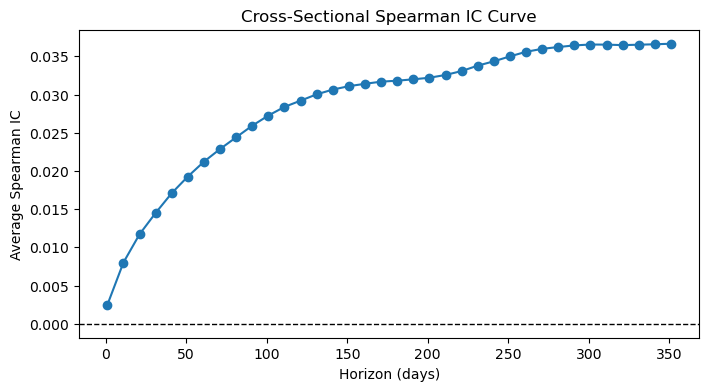

In [12]:
from src.ic_analysis import compute_spearman_ic_curve

horizons = range(1, 361, 10)  
ic_curve = compute_spearman_ic_curve(signal, df_returns, horizons=horizons)

plt.figure(figsize=(8,4))
plt.plot(horizons, ic_curve, marker='o')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel("Horizon (days)")
plt.ylabel("Average Spearman IC")
plt.title("Cross-Sectional Spearman IC Curve")
plt.show()


The Spearman IC measures how well the cross-sectional signal ranks future stock returns across different horizons. In this project, it suggests that the signal’s predictive content is modest but tends to become stronger over longer horizons, which motivated testing longer triple-barrier horizons.

### Targets via Triple Barrier

The triple-barrier labels are generated using the `simple_triple_barrier_labels` function imported from `src/triple_barrier.py`. In the current implementation, the barriers are defined in return space using rolling volatility, while the side of each trade is inferred from the sign of the primary-strategy weight. A label of 1 is assigned only when the profit-taking barrier is hit first; all other outcomes receive label 0. The baseline labeling run uses a 30-day vertical barrier horizon.

In [13]:
from src.triple_barrier import simple_triple_barrier_labels

labels_rolling_30 = simple_triple_barrier_labels(
    df_returns=df_returns,
    wt=wt,
    horizon=30,
    vol_window=20
)

**Horizon Sensitivity Check**

After constructing the baseline 30-day labels, the triple-barrier method was also evaluated over multiple horizons. The purpose of this check was to understand how the choice of vertical barrier affects the label distribution. This is relevant because changing the horizon alters both the time allowed for the signal to materialize and the width of the volatility-scaled horizontal barriers under the current construction.

**Horizon Results**

The horizon comparison shows that, as the vertical barrier is increased, the overall proportion of positive labels falls. At the same time, the long-side positive-label rate rises slightly, while the short-side positive-label rate falls more strongly. This indicates that longer horizons produce fewer, but more selective, positive trade labels under current labeling rule. The exact numerical results are reported in **Table A** in `tables.ipynb`.

### Secondary Model


The secondary model is implemented using the functions imported from `src/secondary_model.py`. The workflow consists of three main steps: constructing the event-level feature dataset, applying a time-based train/test split, and fitting a logistic-regression baseline classifier.

**Baseline Feature Set**

The final baseline feature set is constructed from quantities available at the trade date. The features used are:

- weights from the primary strategy (normalized z-scores)
- cumulative return over the last 20 days
- cumulative return over the last 60 days
- cumulative return over the last 150 days
- rolling daily volatility over the last 20 days
- rolling daily volatility over the last 60 days
- rolling daily volatility over the last 150 days

In [15]:
from src.secondary_model import build_secondary_dataset, time_split, fit_logistic_baseline

secondary_data = build_secondary_dataset(
    df_returns=df_returns,
    labels=labels_rolling_30,
    vol_window=20
)

train_df, test_df = time_split(secondary_data, split_frac=0.7)

feature_cols = ["weight", "ret_20", "ret_60", "ret_150", "vol_20", "vol_60", "vol_150"]

model, out_test_df = fit_logistic_baseline(
    train_df=train_df,
    test_df=test_df,
    feature_cols=feature_cols
)

              precision    recall  f1-score   support

           0       0.76      0.88      0.82   1077601
           1       0.37      0.20      0.26    378899

    accuracy                           0.71   1456500
   macro avg       0.57      0.54      0.54   1456500
weighted avg       0.66      0.71      0.67   1456500

Test ROC AUC: 0.6132


**Modeling Logic**

The secondary model was initially built using past return features together with a short-horizon rolling volatility measure. Under this first setup, the logistic-regression model produced predicted probabilities that were concentrated well below 0.5, indicating that the classifier was not sufficiently confident in identifying positive trade labels.

Because of this, the first question examined was whether the issue came partly from the label construction rather than from the classifier itself. The triple-barrier horizon was therefore varied across several candidate values in an overnight experiment. The idea was to test whether longer horizons would produce labels that are easier for the secondary model to learn.


**Horizon Experiment**

The horizon experiment showed that increasing the triple-barrier horizon led to a lower overall share of positive labels, meaning that the set of positively labeled trade opportunities became sparser. At the same time, the classifier became more desicive: the probability distribution widened and ROC AUC improved materially, indicating that longer horizons produce fewer, but cleaner and more learnable, signals.

The exact results of the horizon run are reported in **Table B** in `tables.ipynb`.


**Feature Checks**

After establishing the role of the label horizon, the next step was to revisit the feature design while keeping a **30-day horizon** as the working baseline. The main logic behind the feature checks was the following:

- return-based features should capture recent price movement over several horizons
- volatility features should provide information about the recent noise regime
- the secondary model may need explicit volatility information in order to interpret whether a given return move is justified or simply noisy

Several alternatives were tested. Namely, features based only on volatility-adjusted returns (i.e. returns divided by volatility) did not improve the logistic-regression baseline. Likewise, replacing raw returns with risk-adjusted returns alone (while keeping an explicit volatility feature in) did not materially help. The model became more informative only once explicit volatility measures across multiple horizons were introduced alongside return-based features. The experiment suggests that volatility is not redundant: it carries useful information in its own right and helps contextualize return-based signals.

The exact feature-comparison results are reported in **Table C** in `tables.ipynb`.


**Sanity Check: 30-Day vs 150-Day Horizon**

As a final consistency check, the improved feature set was then combined with a longer triple-barrier horizon. It was done to verify that the earlier horizon effect was not specific to the original feature specification. The comparison confirmed that the longer horizon still produced stronger model performance under the richer feature set, even though the number of positive trade labels remained lower.

The experiment supports the earlier interpretation that longer horizons create a trade-off: they generate fewer positive signals, but those signals appear to be cleaner and easier for the secondary model to detect.

The exact comparison between the 30-day and 150-day horizon under the improved feature specification is reported in **Table D** in `tables.ipynb`.